# 01_data_analysis.ipynb

-----

In [1]:
# Data analysis notebook

# This notebook analyzes the processed stock price data, subsegment it in specific dates and
# defines volatility timeframes (crisis periods, elections, historical periods).

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
# Read the dictionary with the cleaned data
import pickle

with open("cleaned_data.pkl", "rb") as f:
    cleaned_data = pickle.load(f)

In [4]:
def timeframe_selector(data: dict, stocks: list, timeframe: str, freq: str):
    
    specific_data = {}
    for key in data.keys():
        ticker, period, frequency = key.split("_")[:3]
        if (ticker in stocks) and (period == timeframe) and (frequency == freq):
            specific_data[key] = data[key]
            
    return specific_data

In [5]:
data_10y_1d = timeframe_selector(cleaned_data,
                   stocks=["AAPL", "MSFT", "IBM", "XOM", "WTM", "KO", "JNJ", "VZ", "KHC", "USB"],
                   timeframe='10y', freq='1d')

In [6]:
len(data_10y_1d.keys())

10

In [8]:
data_10y_1d

{'AAPL_10y_1d_cleaned':                  Close        High         Low        Open     Volume
 Date                                                                 
 2015-10-05   24.895094   25.027683   24.510813   24.692841  208258800
 2015-10-06   25.014200   25.110832   24.668123   24.861387  192787200
 2015-10-07   24.895094   25.117572   24.587221   25.110830  187062400
 2015-10-08   24.607449   24.762510   24.317552   24.762510  247918400
 2015-10-09   25.196228   25.232183   24.605199   24.719809  211064400
 ...                ...         ...         ...         ...        ...
 2025-09-29  254.429993  255.000000  253.009995  254.559998   40127700
 2025-09-30  254.630005  255.919998  253.110001  254.860001   37704300
 2025-10-01  255.449997  258.790009  254.929993  255.039993   48713900
 2025-10-02  257.130005  258.179993  254.149994  256.579987   42630200
 2025-10-03  258.019989  259.239990  253.949997  254.669998   49107000
 
 [2515 rows x 5 columns],
 'MSFT_10y_1d_cleaned':   

Now we're going to create a DataFrame with only the closing prices for the day and the all the stocks

In [ ]:
def close_prices_df_generator(data: dict):
    df = pd.DataFrame()
    for key in data.keys():
        df[key.split('_')[0]] = data[key]['Close']

    return df

data_close_10y_1d = close_prices_df_generator(data_10y_1d)

Let's compute the returns for these stocks

In [18]:
def compute_returns(df: pd.DataFrame) -> pd.Series:
    '''Computes the returns based on the period of the dataframe'''
    df_returns = pd.DataFrame()

    for ticker in df.columns:
        df_returns[f'{ticker}'] = df[f'{ticker}'].pct_change()
    
    df_returns.dropna(inplace=True)
    return df_returns
    

In [20]:
returns_close_10y_1d = compute_returns(data_close_10y_1d)

In [35]:
returns_close_10y_1d['AAPL'].describe()

count    2514.000000
mean        0.001099
std         0.018383
min        -0.128647
25%        -0.007328
50%         0.000994
75%         0.010150
max         0.153288
Name: AAPL, dtype: float64

In [ ]:
def descriptive_statistics(data: pd.DataFrame):
    '''Computes the descriptive statistics for the dataframe containing the stocks'''

    statistics = {}
    for ticker in data.columns:
        series = data[f'{ticker}']
        stats_d = {
            'n_obs': int(series.shape[0]),
            'mean': float(series.mean()),
            'median': float(series.median()), 
            'std': float(series.std()),
            "skewness": float(series.skew()),
            'kurtosis': float(series.kurtosis()),   # Fisher (0 for normal)
            'min': float(series.min()),
            'max': float(series.max()),
            '5%': float(series.quantile(0.05)),
            '25%': float(s.quantile(0.25)),
            '75%': float(s.quantile(0.75)),
            '95%': float(s.quantile(0.95))
        }

        


In [32]:
# Define event windows (adjust as you want)
event_windows = {
    "COVID_crash": ("2020-02-15", "2020-04-30"),
    "Elections_OctNov2024": ("2024-10-01", "2024-11-30"),
    "Tariffs_April2025": ("2025-04-01", "2025-04-30"),
    "Pre_2018": ("2016-01-01", "2017-12-31"),
    "Post_2022": ("2022-01-01", "2023-12-31"),
}

# Validate: convert to datetimes
event_windows_dt = {k: (pd.to_datetime(v[0]), pd.to_datetime(v[1])) for k,v in event_windows.items()}
event_windows_dt

{'COVID_crash': (Timestamp('2020-02-15 00:00:00'),
  Timestamp('2020-04-30 00:00:00')),
 'Elections_OctNov2024': (Timestamp('2024-10-01 00:00:00'),
  Timestamp('2024-11-30 00:00:00')),
 'Tariffs_April2025': (Timestamp('2025-04-01 00:00:00'),
  Timestamp('2025-04-30 00:00:00')),
 'Pre_2018': (Timestamp('2016-01-01 00:00:00'),
  Timestamp('2017-12-31 00:00:00')),
 'Post_2022': (Timestamp('2022-01-01 00:00:00'),
  Timestamp('2023-12-31 00:00:00'))}

In [37]:
data_10y_1d['AAPL_10y_1d_cleaned']

,Close,High,Low,Open,Volume,Return
Date,,,,,,
2015-10-05,24.895094,25.027683,24.510813,24.692841,208258800,NaN
2015-10-06,25.014200,25.110832,24.668123,24.861387,192787200,0.004784
2015-10-07,24.895094,25.117572,24.587221,25.110830,187062400,-0.004762
2015-10-08,24.607449,24.762510,24.317552,24.762510,247918400,-0.011554
2015-10-09,25.196228,25.232183,24.605199,24.719809,211064400,0.023927
...,...,...,...,...,...,...
2025-09-29,254.429993,255.000000,253.009995,254.559998,40127700,-0.004032
2025-09-30,254.630005,255.919998,253.110001,254.860001,37704300,0.000786
2025-10-01,255.449997,258.790009,254.929993,255.039993,48713900,0.003220


In [43]:
event_windows_dt['COVID_crash'][0]

Timestamp('2020-02-15 00:00:00')

In [53]:
data_10y_1d['AAPL_10y_1d_cleaned'].loc[event_windows_dt['COVID_crash'][0]:event_windows_dt['COVID_crash'][1]]['Close']

Date
2020-02-18    77.225601
2020-02-19    78.344025
2020-02-20    77.540268
2020-02-21    75.785164
2020-02-24    72.185349
2020-02-25    69.740280
2020-02-26    70.846611
2020-02-27    66.215477
2020-02-28    66.176765
2020-03-02    72.337852
2020-03-03    70.040451
2020-03-04    73.289238
2020-03-05    70.911980
2020-03-06    69.970261
2020-03-09    64.436172
2020-03-10    69.076935
2020-03-11    66.677887
2020-03-12    60.093121
2020-03-13    67.292778
2020-03-16    58.635773
2020-03-17    61.213985
2020-03-18    59.715466
2020-03-19    59.257919
2020-03-20    55.495903
2020-03-23    54.316940
2020-03-24    59.766308
2020-03-25    59.437073
2020-03-26    62.564827
2020-03-27    59.974495
2020-03-30    61.686054
2020-03-31    61.560173
2020-04-01    58.321049
2020-04-02    59.294239
2020-04-03    58.442097
2020-04-06    63.540440
2020-04-07    62.804474
2020-04-08    64.411964
2020-04-09    64.876740
2020-04-13    66.150124
2020-04-14    69.490921
2020-04-15    68.856651
2020-04-16 

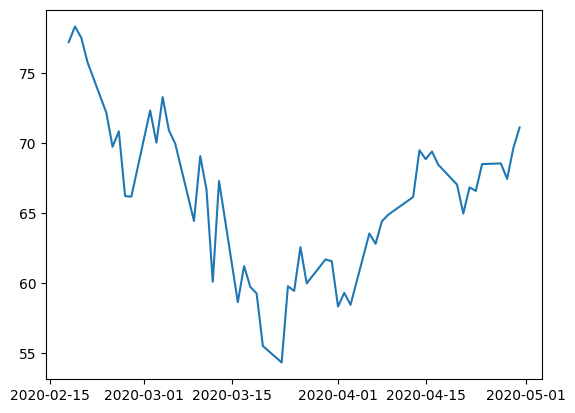

In [54]:
plt.plot(data_10y_1d['AAPL_10y_1d_cleaned'].loc[event_windows_dt['COVID_crash'][0]:event_windows_dt['COVID_crash'][1]]['Close'])

Minute over minute returns and chart those then check its distributions

shapes, mean, kurtosis, skewness, etc... 

Daily: subsegment in specific dates, when markets are more volatile (near crisis = volatility is higher ) march 2020, etc... historical periods.

Tariffs - April 2025
Check extreme returns in the SP500 during the last years
Elections - October / November 2024
